In [1]:
## Pawel Maczuga and Maciej Paszynski 2023

from typing import Callable
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from functools import partial
# from google.colab import files
import time
import os
from typing import Tuple
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device
from PIL import Image
import torch.nn.functional as F

In [2]:
## Parameters - FINAL CORRECTED VERSION
# LENGTH = 1. # Domain size in x axis. Always starts at 0
LENGTH = 2. # Domain size in x axis. Always starts at 0
# TOTAL_TIME = .3 # Domain size in t axis. Always starts at 0
TOTAL_TIME = .5 # Domain size in t axis. Always starts at 0
N_POINTS_INIT = 120 # High resolution for IC
N_POINTS_PDE = 30  # Moderate resolution for PDE
N_POINTS = 30      # Default/Fallback
N_POINTS_PLOT = 150 # Number of points in single axis used in plotting
WEIGHT_RESIDUAL = 0.03 # Weight of residual part of loss function
WEIGHT_INITIAL = 2000.0 # High weight to force IC learning
WEIGHT_BOUNDARY = 0.0005 # Weight of boundary part of loss function
# LAYERS = 4
LAYERS = 4 # Reduced depth for better convergence
# NEURONS_PER_LAYER = 80
NEURONS_PER_LAYER = 64 # Reduced width
EPOCHS = 5_000 # Increased epochs
LEARNING_RATE = 1e-3 # Standard LR
GRAVITY = 1.0 # Reduced for stability


In [3]:
class FourierFeature(nn.Module):
    def __init__(self, input_dim, mapping_size, scale=1.0):
        super().__init__()
        self.input_dim = input_dim
        self.mapping_size = mapping_size
        # Scale=1.0 is CRITICAL for learning the smooth Gaussian hill
        self.B = nn.Parameter(torch.randn(input_dim, mapping_size) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = 2 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class PINN(nn.Module):
    def __init__(self, num_hidden: int, dim_hidden: int, act=nn.Tanh()):
        super().__init__()
        # Fourier embedding: Input (3) -> Encoded (64*2)
        self.fourier = FourierFeature(3, 64, scale=1.0) 
        input_size_encoded = 64 * 2
        
        self.layer_in = nn.Linear(input_size_encoded, dim_hidden)
        self.layer_out = nn.Linear(dim_hidden, 1)
        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

    def forward(self, x, y, t):
        x_stack = torch.cat([x, y, t], dim=1)
        x_encoded = self.fourier(x_stack)
        out = self.act(self.layer_in(x_encoded))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        logits = self.layer_out(out)
        return logits

    def device(self):
        return next(self.parameters()).device


## Loss function

In [4]:
def get_boundary_points(x_domain, y_domain, t_domain, n_points, device = torch.device("cpu"), requires_grad=True):
    """
         .+------+
       .' |    .'|
      +---+--+'  |
      |   |  |   |
    y |  ,+--+---+
      |.'    | .' t
      +------+'
         x
    """
    x_linspace = torch.linspace(x_domain[0], x_domain[1], n_points)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], n_points)
    t_linspace = torch.linspace(t_domain[0], t_domain[1], n_points)

    x_grid, t_grid = torch.meshgrid( x_linspace, t_linspace, indexing="ij")
    y_grid, _      = torch.meshgrid( y_linspace, t_linspace, indexing="ij")

    x_grid = x_grid.reshape(-1, 1).to(device)
    x_grid.requires_grad = requires_grad
    y_grid = y_grid.reshape(-1, 1).to(device)
    y_grid.requires_grad = requires_grad
    t_grid = t_grid.reshape(-1, 1).to(device)
    t_grid.requires_grad = requires_grad

    x0 = torch.full_like(t_grid, x_domain[0], requires_grad=requires_grad)
    x1 = torch.full_like(t_grid, x_domain[1], requires_grad=requires_grad)
    y0 = torch.full_like(t_grid, y_domain[0], requires_grad=requires_grad)
    y1 = torch.full_like(t_grid, y_domain[1], requires_grad=requires_grad)

    down    = (x_grid, y0,     t_grid)
    up      = (x_grid, y1,     t_grid)
    left    = (x0,     y_grid, t_grid)
    right   = (x1,     y_grid, t_grid)

    return down, up, left, right

In [5]:
def get_initial_points(x_domain, y_domain, t_domain, n_points, device = torch.device("cpu"), requires_grad=True):
    x_linspace = torch.linspace(x_domain[0], x_domain[1], n_points)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], n_points)
    x_grid, y_grid = torch.meshgrid( x_linspace, y_linspace, indexing="ij")
    x_grid = x_grid.reshape(-1, 1).to(device)
    x_grid.requires_grad = requires_grad
    y_grid = y_grid.reshape(-1, 1).to(device)
    y_grid.requires_grad = requires_grad
    t0 = torch.full_like(x_grid, t_domain[0], requires_grad=requires_grad)
    return (x_grid, y_grid, t0)

In [6]:
def get_interior_points(x_domain, y_domain, t_domain, n_points, device = torch.device("cpu"), requires_grad=True):
    x_raw = torch.linspace(x_domain[0], x_domain[1], steps=n_points, requires_grad=requires_grad)
    y_raw = torch.linspace(y_domain[0], y_domain[1], steps=n_points, requires_grad=requires_grad)
    t_raw = torch.linspace(t_domain[0], t_domain[1], steps=n_points, requires_grad=requires_grad)
    grids = torch.meshgrid(x_raw, y_raw, t_raw, indexing="ij")

    #W tym miejscu wczytujemy punkty z pliku siatki
    # Czy moglbys napisac tutaj wczytywanie punktow z pliku siatki
    x = grids[0].reshape(-1, 1).to(device)
    y = grids[1].reshape(-1, 1).to(device)
    t = grids[2].reshape(-1, 1).to(device)

    return x, y, t

In [7]:
def f(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    return pinn(x, y, t)

def df(output: torch.Tensor, input: torch.Tensor, order: int = 1) -> torch.Tensor:
    df_value = output
    for _ in range(order):
        df_value = torch.autograd.grad(
            df_value,
            input,
            grad_outputs=torch.ones_like(input),
            create_graph=True,
            retain_graph=True,
        )[0]
    return df_value

def dfdt(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, t, order=order)

def dfdx(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, x, order=order)

def dfdy(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, y, order=order)


In [8]:
class Loss:
    def __init__(
        self,
        x_domain: Tuple[float, float],
        y_domain: Tuple[float, float],
        t_domain: Tuple[float, float],
        n_points_pde: int,
        n_points_init: int,
        initial_condition: Callable,
        floor: Callable,
        weight_r: float = 1.0,
        weight_b: float = 1.0,
        weight_i: float = 1.0,
        verbose: bool = False,
    ):
        self.x_domain = x_domain
        self.y_domain = y_domain
        self.t_domain = t_domain
        self.n_points_pde = n_points_pde
        self.n_points_init = n_points_init
        self.initial_condition = initial_condition
        self.floor = floor
        self.weight_r = weight_r
        self.weight_b = weight_b
        self.weight_i = weight_i

    def residual_loss(self, pinn: PINN):
        x, y, t = get_interior_points(self.x_domain, self.y_domain, self.t_domain, self.n_points_pde, pinn.device())
        u = f(pinn, x, y, t)
        z = self.floor(x, y)
        
        u_t_tt = dfdt(pinn, x, y, t, order=2)
        u_x = dfdx(pinn, x, y, t, order=1)
        u_xx = dfdx(pinn, x, y, t, order=2)
        u_y = dfdy(pinn, x, y, t, order=1)
        u_yy = dfdy(pinn, x, y, t, order=2)
        
        # Topography Gradients with create_graph=False to avoid RuntimeError
        dzdx = torch.autograd.grad(z, x, grad_outputs=torch.ones_like(z), create_graph=False, retain_graph=True)[0]
        dzdy = torch.autograd.grad(z, y, grad_outputs=torch.ones_like(z), create_graph=False, retain_graph=True)[0]
        
        # Shallow Water Equations
        term_x = (u_x - dzdx) * u_x + (u - z) * u_xx
        term_y = (u_y - dzdy) * u_y + (u - z) * u_yy
        
        loss = u_t_tt - GRAVITY * (term_x + term_y)
        return loss.pow(2).mean()

    def initial_loss(self, pinn: PINN):
        x, y, t = get_initial_points(self.x_domain, self.y_domain, self.t_domain, self.n_points_init, pinn.device())
        pinn_init = self.initial_condition(x, y)
        loss = f(pinn, x, y, t) - pinn_init
        return loss.pow(2).mean()

    def boundary_loss(self, pinn: PINN):
        down, up, left, right = get_boundary_points(self.x_domain, self.y_domain, self.t_domain, self.n_points_pde, pinn.device())
        x_down,  y_down,  t_down    = down
        x_up,    y_up,    t_up      = up
        x_left,  y_left,  t_left    = left
        x_right, y_right, t_right   = right

        loss_down  = dfdy( pinn, x_down,  y_down,  t_down  )
        loss_up    = dfdy( pinn, x_up,    y_up,    t_up    )
        loss_left  = dfdx( pinn, x_left,  y_left,  t_left  )
        loss_right = dfdx( pinn, x_right, y_right, t_right )

        return loss_down.pow(2).mean()  + \
            loss_up.pow(2).mean()    + \
            loss_left.pow(2).mean()  + \
            loss_right.pow(2).mean()

    def verbose(self, pinn: PINN, only_initial=False):
        residual_loss = self.residual_loss(pinn)
        initial_loss = self.initial_loss(pinn)
        boundary_loss = self.boundary_loss(pinn)

        final_loss = \
            self.weight_r * residual_loss + \
            self.weight_i * initial_loss + \
            self.weight_b * boundary_loss

        if only_initial:
          final_loss = \
            self.weight_r * residual_loss + \
            self.weight_i * initial_loss + \
            self.weight_b * boundary_loss

        return final_loss, residual_loss, initial_loss, boundary_loss

    def __call__(self, pinn: PINN, only_initial=False):
        return self.verbose(pinn, only_initial)


## Train function

In [9]:
def train_model(
    nn_approximator: PINN,
    loss_fn: Callable,
    learning_rate: int = 0.01,
    max_epochs: int = 1_000,
    pretrain_epochs: int = 1_000
) -> PINN:

    optimizer = torch.optim.Adam(nn_approximator.parameters(), lr=learning_rate)
    loss_values = []
    residual_loss_values = []
    initial_loss_values = []
    boundary_loss_values = []

    start_time = time.time()

    # PRE-TRAINING PHASE: Initial Condition ONLY
    print(f"Starting Pre-training for {pretrain_epochs} epochs (Initial Condition Only)...")
    for epoch in range(pretrain_epochs):
        optimizer.zero_grad()
        # Calculate only initial loss
        loss_tuple = loss_fn(nn_approximator, only_initial=True)
        # loss_tuple is (final_loss, residual, initial, boundary)
        # only_initial=True usually returns the same tuple but weighted differently or just calculates components
        # In the current implementation of verbose, it returns weighted sum. 
        # We want to minimize ONLY initial loss here to force the shape.
        # Let's manually access the initial loss component if possible, or trust the loss_fn configuration.
        # Actually loss_fn.verbose returns (final, res, init, bound).
        # To strictly optimize only INIT, we should backward on loss_tuple[2].
        loss = loss_tuple[2] # Initial Loss
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f"Pretrain Epoch: {epoch + 1} - Initial Loss: {loss.item():.4e}")

    # FULL TRAINING PHASE
    print(f"Starting Full Training for {max_epochs} epochs...")
    for epoch in range(max_epochs):
        try:
            loss_tuple = loss_fn(nn_approximator)
            loss = loss_tuple[0] # Weighted sum
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_values.append(loss_tuple[0].item())
            residual_loss_values.append(loss_tuple[1].item())
            initial_loss_values.append(loss_tuple[2].item())
            boundary_loss_values.append(loss_tuple[3].item())
            if (epoch + 1) % 1000 == 0:
                epoch_time = time.time() - start_time
                start_time = time.time()
                print(f"Epoch: {epoch + 1} - Loss: {float(loss_tuple[0].item()):.4e}, Residual: {float(loss_tuple[1].item()):.4e}, Init: {float(loss_tuple[2].item()):.4e}, Bound: {float(loss_tuple[3].item()):.4e}")

        except KeyboardInterrupt:
            break

    return nn_approximator, np.array(loss_values), np.array(residual_loss_values), np.array(initial_loss_values), np.array(boundary_loss_values)


## Plotting functions

In [10]:
def plot_solution(pinn: PINN, x: torch.Tensor, t: torch.Tensor, figsize=(8, 6), dpi=100):

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x_raw = torch.unique(x).reshape(-1, 1)
    t_raw = torch.unique(t)

    def animate(i):

        if not i % 10 == 0:
            t_partial = torch.ones_like(x_raw) * t_raw[i]
            f_final = f(pinn, x_raw, t_partial)
            ax.clear()
            ax.plot(
                x_raw.detach().numpy(), f_final.detach().numpy(), label=f"Time {float(t[i])}"
            )
            ax.set_ylim(-1, 1)
            ax.legend()

    n_frames = t_raw.shape[0]
    return FuncAnimation(fig, animate, frames=n_frames, interval=100, repeat=False)

def plot_color(z: torch.Tensor, x: torch.Tensor, y: torch.Tensor, n_points_x, n_points_t, title, figsize=(8, 6), dpi=100, cmap="viridis", vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    y_raw = y.detach().cpu().numpy()
    X = x_raw.reshape(n_points_x, n_points_t)
    Y = y_raw.reshape(n_points_x, n_points_t)
    Z = z_raw.reshape(n_points_x, n_points_t)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    c = ax.pcolormesh(X, Y, Z, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(c, ax=ax)

    return fig

def plot_3D(z: torch.Tensor, x: torch.Tensor, y: torch.Tensor, n_points_x, n_points_t, title, figsize=(8, 6), dpi=100, limit=0.2):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(projection='3d')
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    y_raw = y.detach().cpu().numpy()
    X = x_raw.reshape(n_points_x, n_points_t)
    Y = y_raw.reshape(n_points_x, n_points_t)
    Z = z_raw.reshape(n_points_x, n_points_t)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axes.set_zlim3d(bottom=-limit, top=limit)

    c = ax.plot_surface(X, Y, Z)

    x_floor = torch.linspace(0.0, LENGTH, 50)
    y_floor = torch.linspace(0.0, LENGTH, 50)
    z_floor = torch.zeros((50, 50))
    for x_idx, x_coord in enumerate(x_floor):
        for y_idx, y_coord in enumerate(y_floor):
            z_floor[x_idx, y_idx] = floor(x_coord, y_coord)
    x_floor = torch.tile(x_floor, (50, 1))
    y_floor = torch.tile(y_floor, (50, 1)).T
    f = ax.plot_surface(x_floor, y_floor, z_floor, color='green', alpha=0.7)

    return fig

def running_average(y, window=100):
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)

def plot_3D(z: torch.Tensor, x: torch.Tensor, y: torch.Tensor, n_points_x, n_points_t, title, figsize=(8, 6), dpi=100, limit=0.2):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(projection='3d')
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    y_raw = y.detach().cpu().numpy()
    X = x_raw.reshape(n_points_x, n_points_t)
    Y = y_raw.reshape(n_points_x, n_points_t)
    Z = z_raw.reshape(n_points_x, n_points_t)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axes.set_zlim3d(bottom=-limit, top=limit)

    c = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

    # Plot Floor - Vectorized
    x_f = torch.linspace(0.0, LENGTH, 50).to(z.device)
    y_f = torch.linspace(0.0, LENGTH, 50).to(z.device)
    X_f, Y_f = torch.meshgrid(x_f, y_f, indexing='ij')
    
    # Flatten for floor function
    xf_flat = X_f.reshape(-1, 1)
    yf_flat = Y_f.reshape(-1, 1)
    
    Z_f_flat = floor(xf_flat, yf_flat)
    Z_f = Z_f_flat.reshape(50, 50).detach().cpu().numpy()
    
    X_f_np = X_f.detach().cpu().numpy()
    Y_f_np = Y_f.detach().cpu().numpy()
    
    f = ax.plot_surface(X_f_np, Y_f_np, Z_f, color='green', alpha=0.5)

    return fig


In [11]:
# Initial condition
def initial_condition(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    r = torch.sqrt((x-LENGTH/2)**2 + (y-LENGTH/2)**2)
    # Standard Gaussian pulse
    res = 1.0 * torch.exp(-(r)**2 * 30) + 2.0 
    return res

# Load Topography
try:
    img = Image.open('topography.png').convert('L')
    img_data = np.array(img).astype(np.float32) / 255.0 
    img_data = img_data * 1.0 
    TOPOGRAPHY_TENSOR = torch.tensor(img_data).unsqueeze(0).unsqueeze(0).to(device)
    print("Topography loaded:", TOPOGRAPHY_TENSOR.shape)
except Exception as e:
    print(f"Error loading topography: {e}")
    TOPOGRAPHY_TENSOR = torch.zeros((1, 1, 256, 256)).to(device)

def floor(x, y):
    """Get the sea floor value using grid_sample"""
    if x.ndim == 0:
        x = x.view(1, 1)
        y = y.view(1, 1)
        
    # Map [0, LENGTH] to [-1, 1]
    grid_x = 2.0 * (x / LENGTH) - 1.0
    grid_y = 2.0 * (y / LENGTH) - 1.0
    
    grid = torch.cat([grid_x, grid_y], dim=1) 
    grid = grid.unsqueeze(0).unsqueeze(2) 
    
    # BICUBIC INTERPOLATION for smooth gradients
    z = F.grid_sample(TOPOGRAPHY_TENSOR.to(x.device), grid, mode='bicubic', align_corners=True)
    return z.view(-1, 1)


Topography loaded: torch.Size([1, 1, 256, 256])


# Running code

## Train data

Starting Pre-training for 2000 epochs (Initial Condition Only)...


c:\Users\lopma\Education\Studies\sem9\continuous-process-simulation-and-adaptive-algorithms\pinn-labs\.venv\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Pretrain Epoch: 500 - Initial Loss: 1.2741e-04
Pretrain Epoch: 1000 - Initial Loss: 2.3198e-05
Pretrain Epoch: 1500 - Initial Loss: 7.9329e-06
Pretrain Epoch: 2000 - Initial Loss: 3.8987e-06
Starting Full Training for 3000 epochs...
Epoch: 1000 - Loss: 5.7996e-02, Residual: 1.3510e+00, Init: 8.4498e-06, Bound: 1.1297e+00
Epoch: 2000 - Loss: 1.8816e-02, Residual: 3.6457e-01, Init: 3.6993e-06, Bound: 9.6133e-01
Epoch: 3000 - Loss: 1.1259e-02, Residual: 1.9052e-01, Init: 2.5508e-06, Bound: 8.8321e-01
Total loss: 	0.01065 (1.065E-02)
Interior loss: 	0.19078 (1.908E-01)
Initial loss: 	0.00000 (2.241E-06)
Bondary loss: 	0.88492 (8.849E-01)


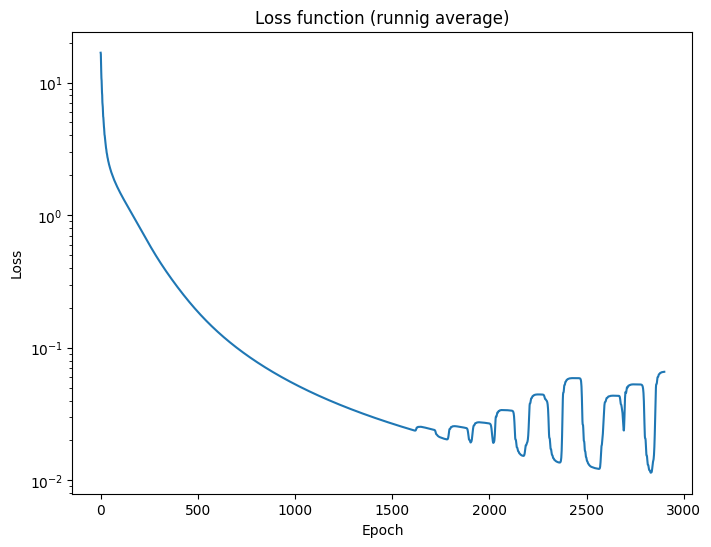

In [12]:
pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)

x_domain = [0.0, LENGTH]
y_domain = [0.0, LENGTH]
t_domain = [0.0, TOTAL_TIME]

# train the PINN
loss_fn = Loss(
    x_domain,
    y_domain,
    t_domain,
    N_POINTS_PDE,
    N_POINTS_INIT,
    initial_condition,
    floor,
    weight_r=WEIGHT_RESIDUAL,
    weight_i=WEIGHT_INITIAL,
    weight_b=WEIGHT_BOUNDARY
)

# Pre-train for 2000 epochs to stabilize IC
pinn_trained, loss_values, residual_loss_values, initial_loss_values, boundary_loss_values = train_model(
    pinn, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS, pretrain_epochs=2000)

pinn = pinn.cpu()
losses = loss_fn.verbose(pinn)
print(f'Total loss: \t{losses[0]:.5f} ({losses[0]:.3E})')
print(f'Interior loss: \t{losses[1]:.5f} ({losses[1]:.3E})')
print(f'Initial loss: \t{losses[2]:.5f} ({losses[2]:.3E})')
print(f'Bondary loss: \t{losses[3]:.5f} ({losses[3]:.3E})')

# Plotting

# Loss function
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (runnig average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')


Verifying Initial Condition Learning...
Final IC MSE: 0.000002
SUCCESS: IC MSE is low. Wave structure learned.


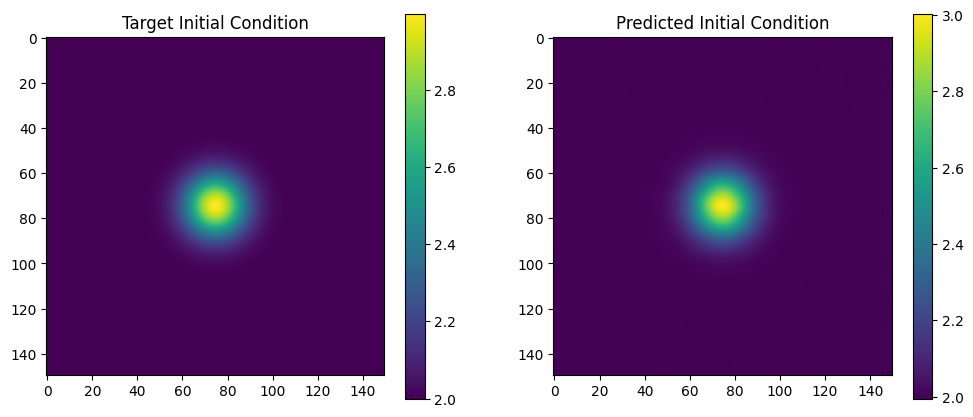

In [13]:
# DEBUG: Verify Initial Condition Learning
print("Verifying Initial Condition Learning...")
x_deb, y_deb, _ = get_initial_points(x_domain, y_domain, t_domain, N_POINTS_PLOT, requires_grad=False)
z_target = initial_condition(x_deb, y_deb)
t0 = torch.zeros_like(x_deb)
z_pred = pinn(x_deb, y_deb, t0)

check_mse = ((z_pred - z_target)**2).mean().item()
print(f"Final IC MSE: {check_mse:.6f}")

if check_mse > 0.1:
    print("WARNING: IC MSE is high! The wave might not have formed.")
else:
    print("SUCCESS: IC MSE is low. Wave structure learned.")

# Plot Target vs Prediction slice
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax[0].imshow(z_target.reshape(N_POINTS_PLOT, N_POINTS_PLOT).cpu().numpy(), cmap='viridis')
ax[0].set_title("Target Initial Condition")
plt.colorbar(im1, ax=ax[0])

im2 = ax[1].imshow(z_pred.reshape(N_POINTS_PLOT, N_POINTS_PLOT).detach().cpu().numpy(), cmap='viridis')
ax[1].set_title("Predicted Initial Condition")
plt.colorbar(im2, ax=ax[1])
plt.show()


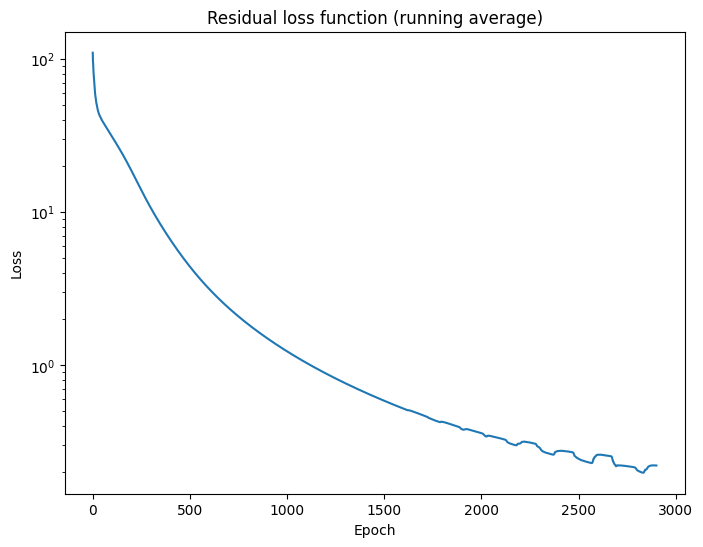

In [14]:
average_loss = running_average(residual_loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Residual loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')


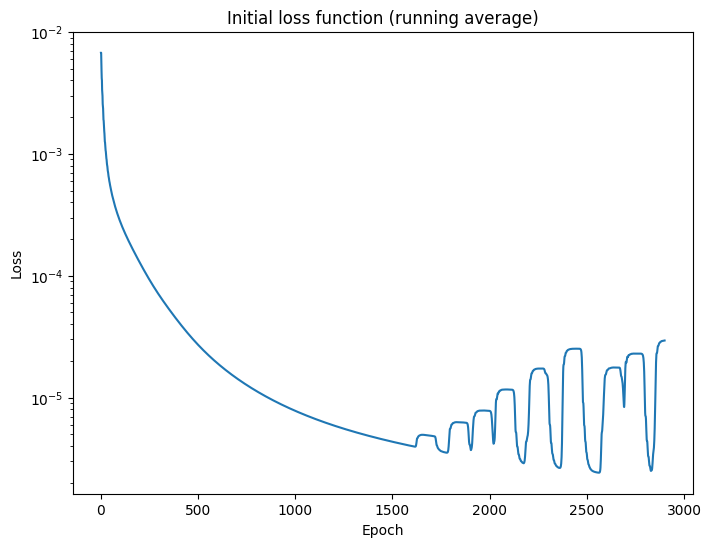

In [15]:
average_loss = running_average(initial_loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Initial loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')

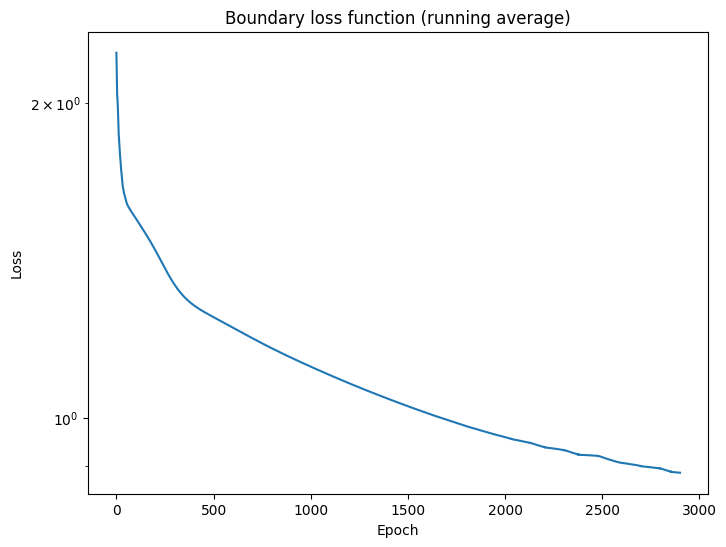

In [16]:
average_loss = running_average(boundary_loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Boundary loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')

In [17]:
# Plotting and GIF generation with GLOBAL DYNAMIC SCALING
base_dir = '.'
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Ensure output directories exist
os.makedirs(base_dir + '/img', exist_ok=True)

print("Starting GIF generation with GLOBAL DYNAMIC SCALING...")

# Define time values for animation matching the domain
time_values_np = np.arange(0, TOTAL_TIME, 0.01)
time_values = torch.tensor(time_values_np, dtype=torch.float32).to(pinn.device())

# 1. Pre-compute frames to determine global scale
print("Pre-computing frames to determine global min/max scale...")
frames_z_min = []
frames_z_max = []

# Need x, y for plotting grid (get_initial_points gives us the grid)
# We use x, y from previous cell or re-generate
x, y, _ = get_initial_points(x_domain, y_domain, t_domain, N_POINTS_PLOT, requires_grad=False)

for t_val in time_values:
    t_tensor = torch.full_like(x, t_val)
    with torch.no_grad():
        z = pinn(x, y, t_tensor)
        frames_z_min.append(z.min().item())
        frames_z_max.append(z.max().item())

# Compute global min/max across ALL frames
all_min = min(frames_z_min)
all_max = max(frames_z_max)
print(f"Global Scale determined: Min={all_min:.4f}, Max={all_max:.4f}")

# 2. Generate Frames with Unified Scale
print("Generating frames...")
for idx, t_val in enumerate(time_values_np):
    t_tensor = torch.full_like(x, t_val)
    with torch.no_grad():
        z = pinn(x, y, t_tensor)
    
    # Create figure with FIXED global scale
    fig = plot_color(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, f"PINN for t = {t_val:.2f}", vmin=all_min, vmax=all_max)
    plt.savefig(base_dir + '/img/img_{:03d}.png'.format(idx))
    plt.close(fig) # Close to prevent embedding
    if idx % 10 == 0: print(f"Generated frame {idx}/{len(time_values_np)}")


Starting GIF generation with GLOBAL DYNAMIC SCALING...
Pre-computing frames to determine global min/max scale...
Global Scale determined: Min=1.5211, Max=3.0037
Generating frames...
Generated frame 0/50
Generated frame 10/50
Generated frame 20/50
Generated frame 30/50
Generated frame 40/50


In [18]:
import imageio
frames = []
for idx in range(len(time_values)):
    image = imageio.v2.imread(base_dir + '/img/img_{:03d}.png'.format(idx))
    frames.append(image)

imageio.mimsave('./tsunami_wave12.gif', # output gif
                frames, # array of input frames
                duration=0.1) # optional: frames per secondd